In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from src.simulate import generate_normal_data,inject_disk_degradation,inject_io_error_burst,inject_latency_spike, inject_node_failure
%matplotlib inline

In [2]:
df = generate_normal_data(n_rows=10000, seed=42)

In [3]:
df.head()

,timestamp,userDataReadIops,userDataWriteIops,readLatencyMs,writeLatencyMs,cpuPercent,memoryPercent,label
0,2026-01-01 00:00:00,4099.342831,2298.225790,2.174143,2.009714,37.640712,60.491031,0
1,2026-01-01 00:01:00,3972.356659,2354.180792,2.141662,2.472507,45.063512,59.679459,0
2,2026-01-01 00:02:00,4129.575785,2310.415687,1.531740,2.706486,39.009066,64.758954,0
3,2026-01-01 00:03:00,4304.691644,2416.614110,2.289792,3.074834,40.452846,67.664156,0
4,2026-01-01 00:04:00,3953.321630,2579.668163,1.254959,3.512081,43.586953,63.434235,0


In [4]:
used_indices = np.zeros(len(df), dtype=int)  # 0 means normal, 1-4 for anomalies
df, used_indices = inject_disk_degradation(df, used_indices)
df, used_indices = inject_io_error_burst(df, used_indices)
df, used_indices = inject_latency_spike(df, used_indices)
df, used_indices = inject_node_failure(df, used_indices)

In [5]:
df.head()

,timestamp,userDataReadIops,userDataWriteIops,readLatencyMs,writeLatencyMs,cpuPercent,memoryPercent,label
0,2026-01-01 00:00:00,4099.342831,2298.225790,2.174143,2.009714,37.640712,60.491031,0
1,2026-01-01 00:01:00,3972.356659,2354.180792,2.141662,2.472507,45.063512,59.679459,0
2,2026-01-01 00:02:00,4129.575785,2310.415687,1.531740,2.706486,39.009066,64.758954,0
3,2026-01-01 00:03:00,4304.691644,2416.614110,2.289792,3.074834,40.452846,67.664156,0
4,2026-01-01 00:04:00,3953.321630,2579.668163,1.254959,3.512081,43.586953,63.434235,0


In [6]:
df['label'].value_counts()

label
0    9100
1     500
3     153
2     142
4     105
Name: count, dtype: int64

In [8]:
df["iops_data_read_rolling_mean_5m"]=df['userDataReadIops'].rolling(window=5).mean()
df["iops_data_read_rolling_std_5m"]=df['userDataReadIops'].rolling(window=5).std()
df["iops_data_read_pct_change_1h"]=df['userDataReadIops'].pct_change(periods=60)


df["iops_data_write_rolling_mean_5m"]=df['userDataWriteIops'].rolling(window=5).mean()
df["iops_data_write_rolling_std_5m"]=df['userDataWriteIops'].rolling(window=5).std()
df["iops_data_write_pct_change_1h"]=df['userDataWriteIops'].pct_change(periods=60)


df["read_latency_rolling_mean_5m"]=df['readLatencyMs'].rolling(window=5).mean()
df["read_latency_rolling_std_5m"]=df['readLatencyMs'].rolling(window=5).std()
df["read_latency_pct_change_1h"]=df['readLatencyMs'].pct_change(periods=60)

df["write_latency_rolling_mean_5m"]=df['writeLatencyMs'].rolling(window=5).mean()
df["write_latency_rolling_std_5m"]=df['writeLatencyMs'].rolling(window=5).std()
df["write_latency_pct_change_1h"]=df['writeLatencyMs'].pct_change(periods=60)

In [12]:
df=df.dropna()

In [13]:
df1.head()

,timestamp,userDataReadIops,userDataWriteIops,readLatencyMs,writeLatencyMs,cpuPercent,memoryPercent,label,iops_data_read_rolling_mean_5m,iops_data_read_rolling_std_5m,iops_data_read_pct_change_1h,iops_data_write_rolling_mean_5m,iops_data_write_rolling_std_5m,iops_data_write_pct_change_1h,read_latency_rolling_mean_5m,read_latency_rolling_std_5m,read_latency_pct_change_1h,write_latency_rolling_mean_5m,write_latency_rolling_std_5m,write_latency_pct_change_1h
60,2026-01-01 01:00:00,3938.239326,2441.417708,2.225206,3.159634,39.301569,58.212759,0,4019.038969,144.643824,-0.039300,2337.333695,144.681146,0.062305,2.146060,0.693686,0.023486,3.077954,0.473671,0.572181
61,2026-01-01 01:01:00,3998.080881,2456.902445,1.735196,3.452344,41.392022,57.956846,0,4046.282991,118.015268,0.006476,2351.826919,153.914178,0.043634,2.014212,0.697317,-0.189790,3.170657,0.496667,0.396293
62,2026-01-01 01:02:00,3815.102552,2554.658290,1.626288,3.075471,34.070572,52.397814,0,4015.518178,156.874498,-0.076151,2429.525350,133.457582,0.105714,1.828592,0.638636,0.061726,3.251690,0.422076,0.136334
63,2026-01-01 01:03:00,3798.303439,2689.779576,2.280207,3.310007,30.144235,57.683916,0,3955.557857,173.798651,-0.117636,2469.317847,178.397082,0.113036,1.760520,0.544286,-0.004186,3.368887,0.303679,0.076483
64,2026-01-01 01:04:00,4201.243469,2218.541534,1.134852,3.208689,38.933098,64.804512,0,3950.193933,163.387840,0.062712,2472.259911,172.962717,-0.139990,1.800350,0.471221,-0.095705,3.241229,0.145338,-0.086385


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9940 entries, 60 to 9999
Data columns (total 20 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   timestamp                        9940 non-null   datetime64[ns]
 1   userDataReadIops                 9940 non-null   float64       
 2   userDataWriteIops                9940 non-null   float64       
 3   readLatencyMs                    9940 non-null   float64       
 4   writeLatencyMs                   9940 non-null   float64       
 5   cpuPercent                       9940 non-null   float64       
 6   memoryPercent                    9940 non-null   float64       
 7   label                            9940 non-null   int64         
 8   iops_data_read_rolling_mean_5m   9940 non-null   float64       
 9   iops_data_read_rolling_std_5m    9940 non-null   float64       
 10  iops_data_read_pct_change_1h     9940 non-null   float64       


Text(0.5, 1.0, 'Class Distribution')

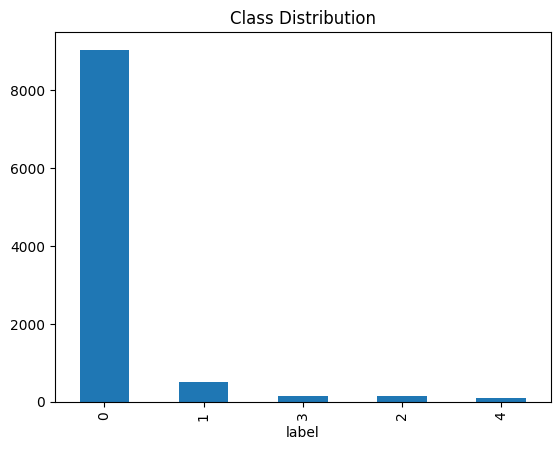

In [24]:
df['label'].value_counts().plot(kind='bar')
plt.title('Class Distribution')

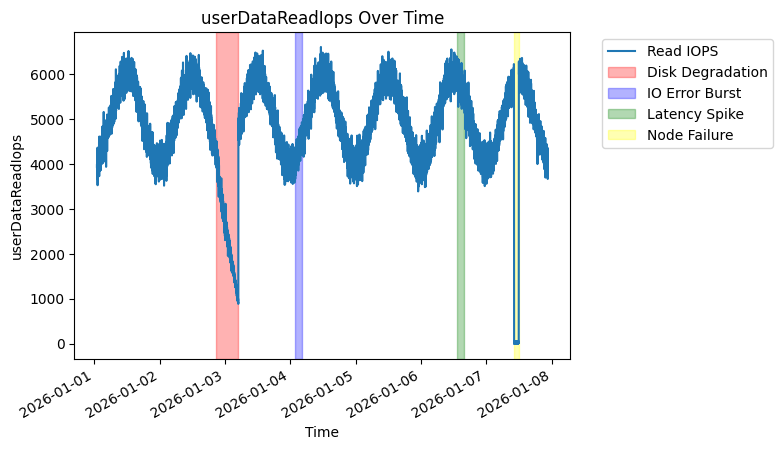

In [33]:
plt.plot(df['timestamp'], df['userDataReadIops'], label='Read IOPS')
plt.title('userDataReadIops Over Time')
plt.xlabel('Time')
plt.ylabel('userDataReadIops')
plt.xticks(rotation=45)
plt.gcf().autofmt_xdate()
plt.axvspan(df[df['label'] == 1]['timestamp'].min(), df[df['label'] == 1]['timestamp'].max(), color='red', alpha=0.3, label='Disk Degradation')
plt.axvspan(df[df['label'] == 2]['timestamp'].min(), df[df['label'] == 2]['timestamp'].max(), color='blue', alpha=0.3, label='IO Error Burst')
plt.axvspan(df[df['label'] == 3]['timestamp'].min(), df[df['label'] == 3]['timestamp'].max(), color='green', alpha=0.3, label='Latency Spike')
plt.axvspan(df[df['label'] == 4]['timestamp'].min(), df[df['label'] == 4]['timestamp'].max(), color='yellow', alpha=0.3, label='Node Failure')
plt.legend().set_bbox_to_anchor((1.05, 1))
plt.show()

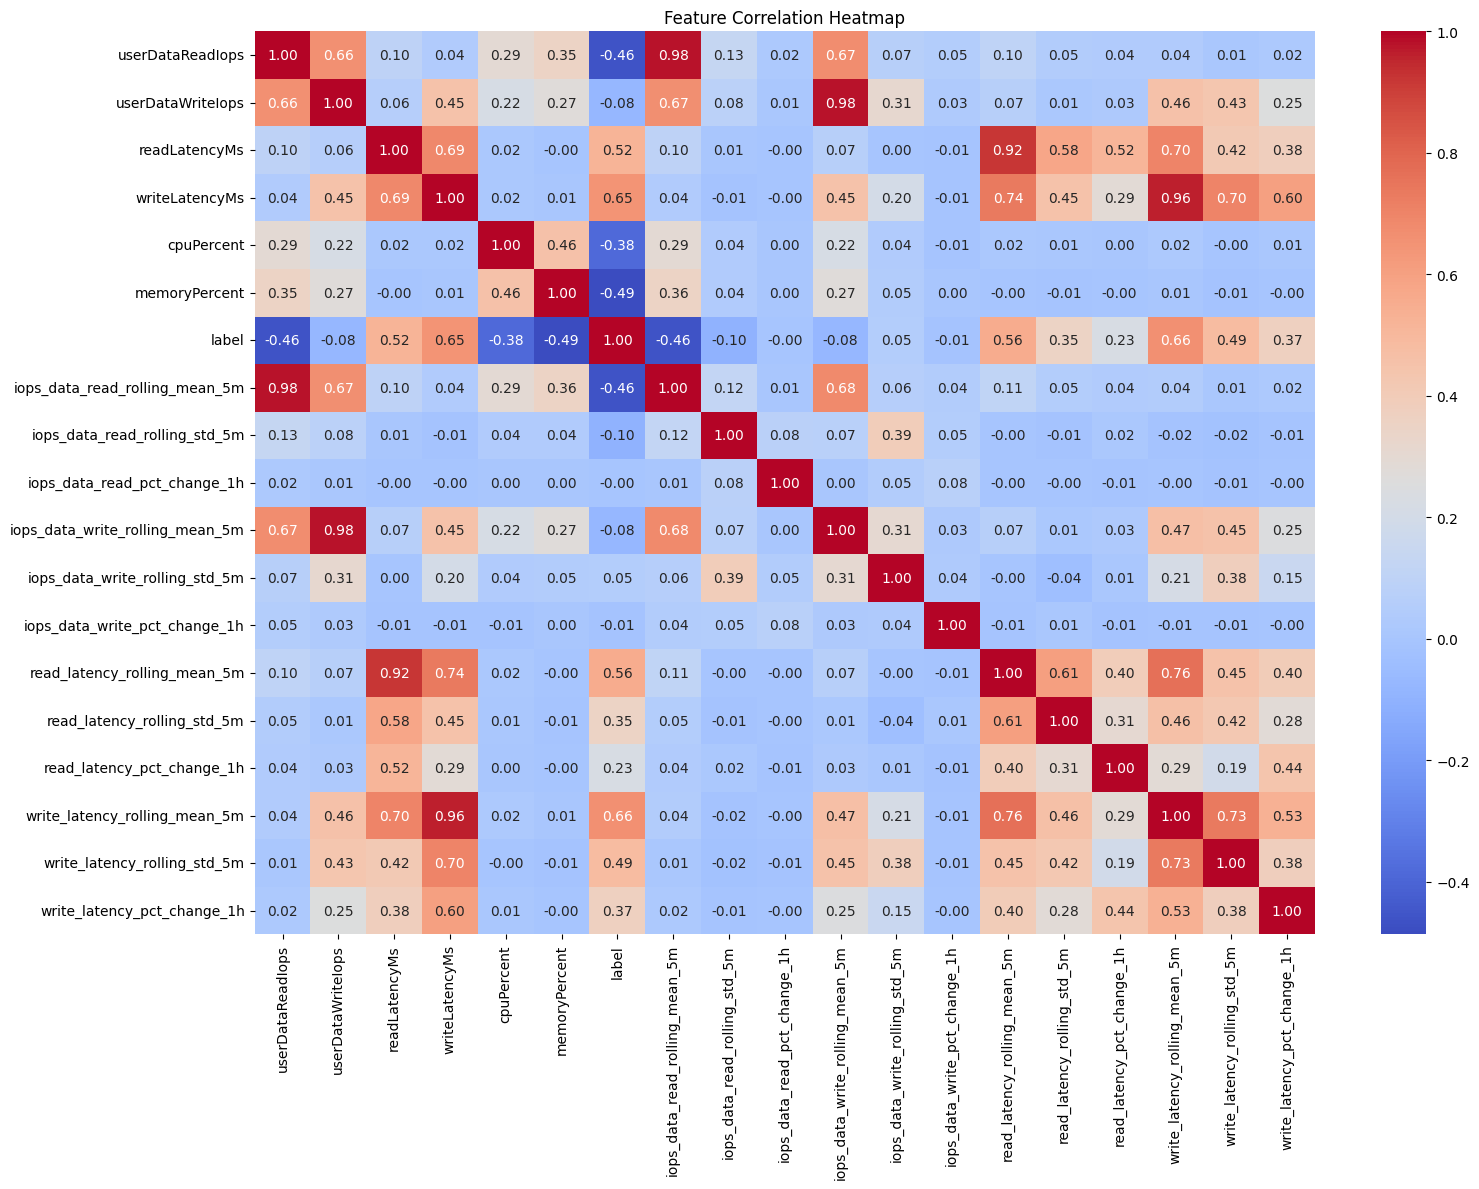

In [40]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'userDataReadIops Distribution by Label')

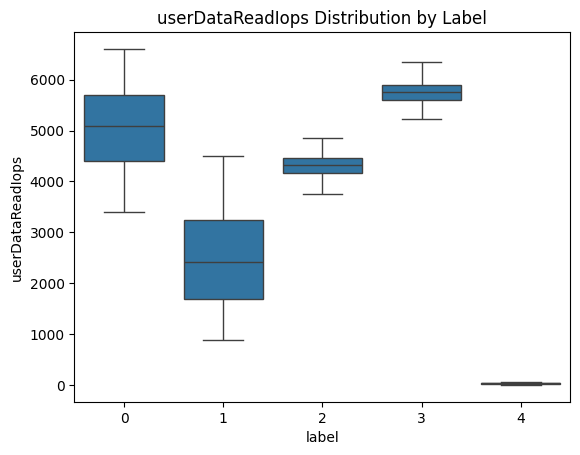

In [43]:
sns.boxplot(x='label', y='userDataReadIops', data=df)
plt.title('userDataReadIops Distribution by Label')

In [44]:
df.to_csv('../data/simulated_data.csv', index=False)